# Task 06 - Model Evaluation



The tuned Logistic Regression, Decision Tree, and Random Forest models
are evaluated using the untouched test dataset.

The following binary classification metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## 1. Import evaluation libraries

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Evaluate all three models

In [79]:
models = {
    "Logistic Regression": best_logistic_model,
    "Decision Tree": best_decision_tree_model,
    "Random Forest": best_random_forest_model
}

evaluation_results = []

for model_name, model in models.items():

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability of class 1 = No-Show
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(evaluation_results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6650,0.6632,0.6495,0.6562,0.7143
1,Decision Tree,0.6193,0.6170,0.5979,0.6073,0.6225
2,Random Forest,0.6396,0.6383,0.6186,0.6283,0.6610


## 3. Confusion matrices

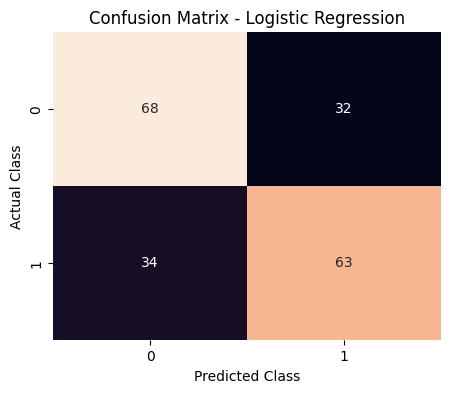

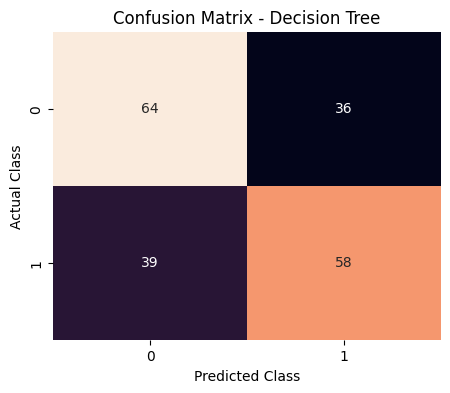

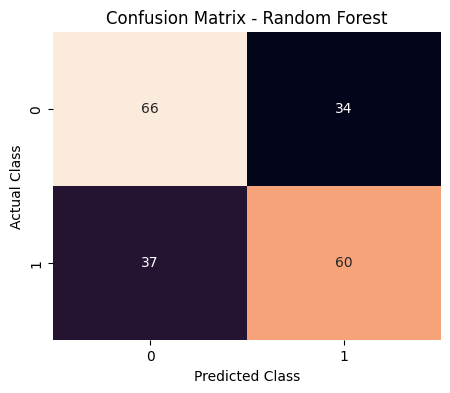

In [80]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

## 4. Classification reports

In [81]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    print("_" * 60)
    print(model_name)
    print("_" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Attended",
                "No-Show"
            ]
        )
    )

____________________________________________________________
Logistic Regression
____________________________________________________________
              precision    recall  f1-score   support

    Attended       0.67      0.68      0.67       100
     No-Show       0.66      0.65      0.66        97

    accuracy                           0.66       197
   macro avg       0.66      0.66      0.66       197
weighted avg       0.66      0.66      0.66       197

____________________________________________________________
Decision Tree
____________________________________________________________
              precision    recall  f1-score   support

    Attended       0.62      0.64      0.63       100
     No-Show       0.62      0.60      0.61        97

    accuracy                           0.62       197
   macro avg       0.62      0.62      0.62       197
weighted avg       0.62      0.62      0.62       197

____________________________________________________________
Random 

## 5. ROC Curves

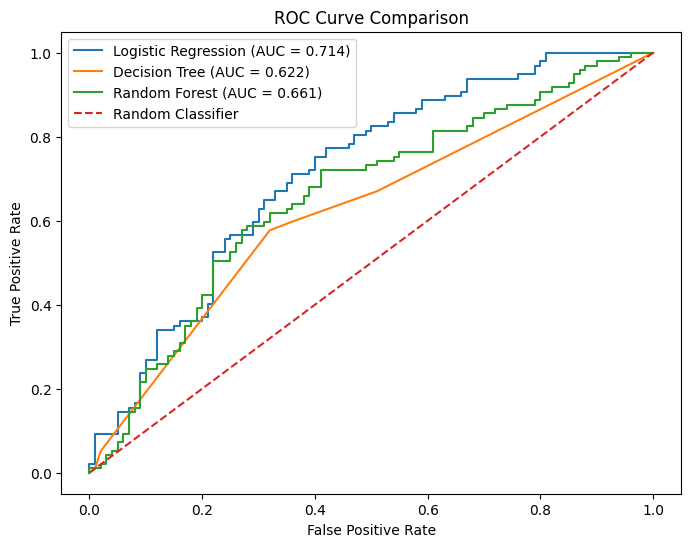

In [82]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## 6. Final model comparison chart

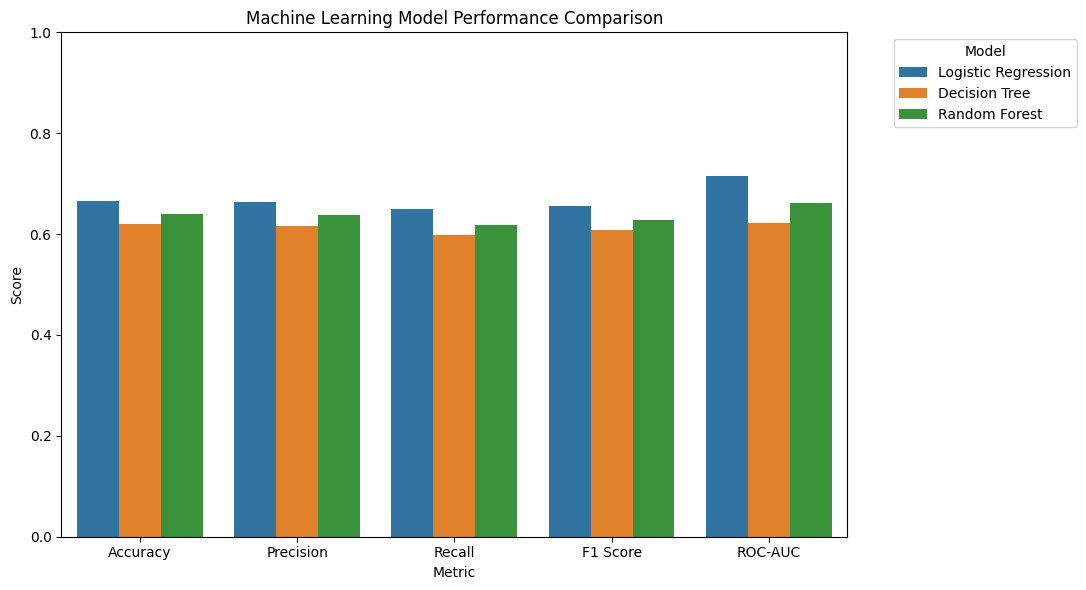

In [83]:
results_long = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## 7. Save the final model

#### Create a model Folder

In [84]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [85]:
import joblib

joblib.dump(
    best_logistic_model,
    "models/smartcare_no_show_model.joblib"
)

print("Best model saved successfully.")

Best model saved successfully.


# **Task 07 - Explainable AI Analysis**



Feature Importance Analysis is used to interpret the selected
Logistic Regression model.

The analysis focuses on:

- Important predictive features
- Direction of feature influence
- Individual prediction reasoning
- Model transparency
- Ethical implications

## 1. Import libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance

## 2. Get Logistic Regression coefficients

In [87]:
# model is inside a Pipeline so first have to extract
fitted_preprocessor = (
    best_logistic_model
    .named_steps["preprocessor"]
)

logistic_classifier = (
    best_logistic_model
    .named_steps["model"]
)

In [88]:
# Get the encoded feature names
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = (
    logistic_classifier
    .coef_[0]
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance_df["Absolute Importance"] = (
    feature_importance_df["Coefficient"].abs()
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Absolute Importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,Feature,Coefficient,Absolute Importance
1,num__waiting_days,0.299849,0.299849
2,num__previous_appointments,-0.156660,0.156660
6,num__previous_no_show_rate,0.085683,0.085683
3,num__missed_previous_appointments,0.069343,0.069343
0,num__age,-0.068576,0.068576
27,cat__diagnosis_Chest Pain,0.067506,0.067506
48,cat__appointment_day_of_week_Monday,-0.064448,0.064448
21,cat__department_Neurology,0.061007,0.061007
47,cat__appointment_day_of_week_Friday,0.044232,0.044232
14,cat__blood_group_B+,0.042310,0.042310


## 3. Plot global coefficient importance

#### Tack the top 15

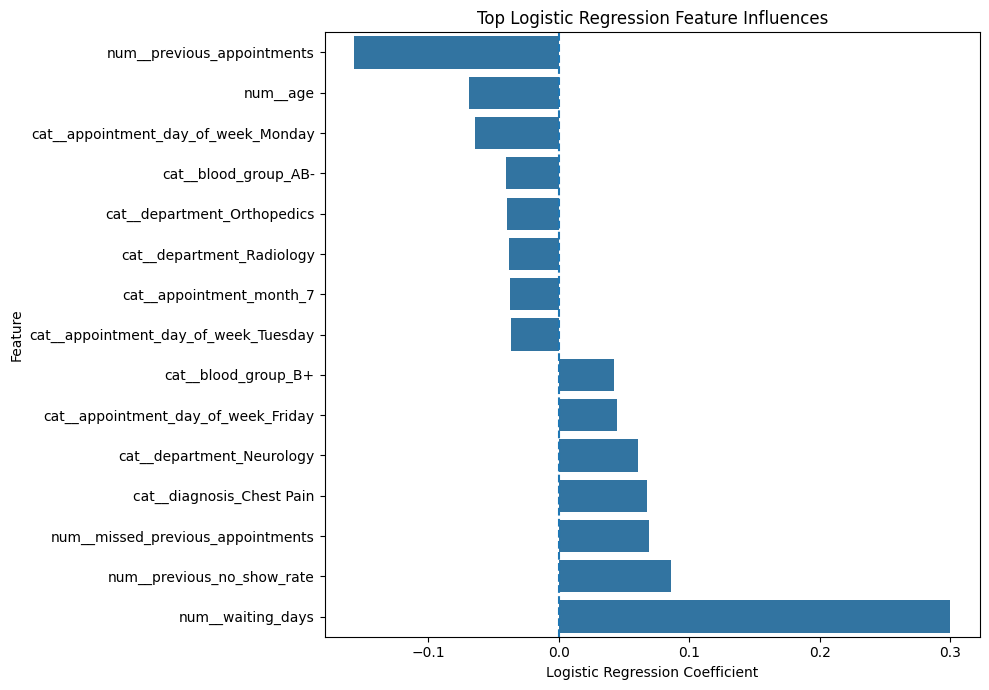

In [89]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by="Coefficient"
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Top Logistic Regression Feature Influences"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

### Coefficient Interpretation

Positive coefficients push predictions toward the No-Show class
(class 1), while negative coefficients push predictions toward the
Attended class (class 0).

The magnitude of the coefficient indicates the strength of the
feature's contribution within the fitted Logistic Regression model.

Waiting days showed the strongest positive influence on no-show
prediction.

Previous no-show behaviour also showed positive influence, supporting
the findings obtained during Exploratory Data Analysis.

## 4. Use Permutation Feature Importance

In [90]:
permutation_result = permutation_importance(
    best_logistic_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

#### Create the table 

In [91]:
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

permutation_df

,Feature,Importance,Std
5,waiting_days,0.160639,0.020752
7,missed_previous_appointments,0.018722,0.006282
12,previous_no_show_rate,0.010469,0.007514
6,previous_appointments,0.003469,0.015092
13,has_previous_no_show,0.003454,0.001524
10,appointment_day_of_week,0.002990,0.003621
9,appointment_month,0.002851,0.003613
4,diagnosis,0.002098,0.002137
11,appointment_is_weekend,0.000871,0.000855
3,department,0.000381,0.004673


## 5. Plot permutation importance

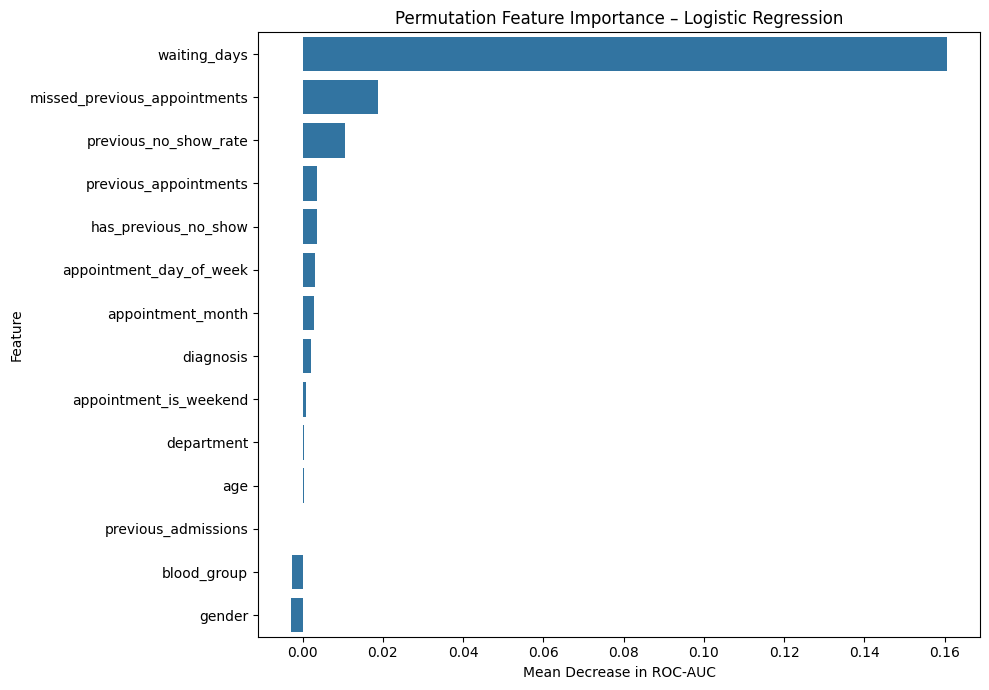

In [92]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=permutation_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Permutation Feature Importance – Logistic Regression"
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

### Permutation Importance Interpretation

Permutation importance showed that **waiting_days** was substantially
more influential than the other selected variables.

When the values of waiting days were randomly disturbed, the model's
ROC-AUC decreased more strongly than when other features were
permuted.

This indicates that the Logistic Regression model relies heavily on
appointment waiting time when distinguishing between attended and
no-show appointments.

Historical appointment behaviour, including missed previous
appointments and previous no-show rate, also contributed to the
prediction process.

## 6. Explain one individual prediction

In [93]:
# We can automatically select a test patient with a high predicted no-show probability
test_probabilities = (
    best_logistic_model
    .predict_proba(X_test)[:, 1]
)

highest_risk_position = np.argmax(
    test_probabilities
)

sample_index = (
    X_test.index[
        highest_risk_position
    ]
)

sample_patient = (
    X_test.loc[[sample_index]]
)

sample_patient

,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,appointment_month,appointment_day_of_week,appointment_is_weekend,previous_no_show_rate,has_previous_no_show
890,32,Male,AB-,Orthopedics,Asthma,37,1,1,0,4,Wednesday,0,1.0,1


In [94]:
#### Get Prediction
sample_prediction = (
    best_logistic_model
    .predict(sample_patient)[0]
)

sample_probability = (
    best_logistic_model
    .predict_proba(sample_patient)[0, 1]
)

print(
    "Predicted Class:",
    sample_prediction
)

print(
    "No-Show Probability:",
    round(sample_probability, 4)
)

Predicted Class: 1
No-Show Probability: 0.701


## 7. Calculate contributions for that patient

In [95]:
sample_processed = (
    fitted_preprocessor
    .transform(sample_patient)
)

if hasattr(
    sample_processed,
    "toarray"
):
    sample_processed = (
        sample_processed
        .toarray()
    )

sample_values = (
    sample_processed[0]
)

sample_contributions = (
    sample_values
    * logistic_classifier.coef_[0]
)

local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": sample_contributions
})

local_explanation[
    "Absolute Contribution"
] = (
    local_explanation[
        "Contribution"
    ].abs()
)

local_explanation = (
    local_explanation
    .sort_values(
        by="Absolute Contribution",
        ascending=False
    )
)

local_explanation.head(10)

,Feature,Contribution,Absolute Contribution
1,num__waiting_days,0.347182,0.347182
6,num__previous_no_show_rate,0.252712,0.252712
2,num__previous_appointments,0.179969,0.179969
0,num__age,0.049888,0.049888
3,num__missed_previous_appointments,0.041209,0.041209
13,cat__blood_group_AB-,-0.040483,0.040483
22,cat__department_Orthopedics,-0.039605,0.039605
25,cat__diagnosis_Asthma,0.035453,0.035453
53,cat__appointment_day_of_week_Wednesday,0.033682,0.033682
41,cat__appointment_month_4,-0.026555,0.026555


## 8. Plot individual prediction explanation

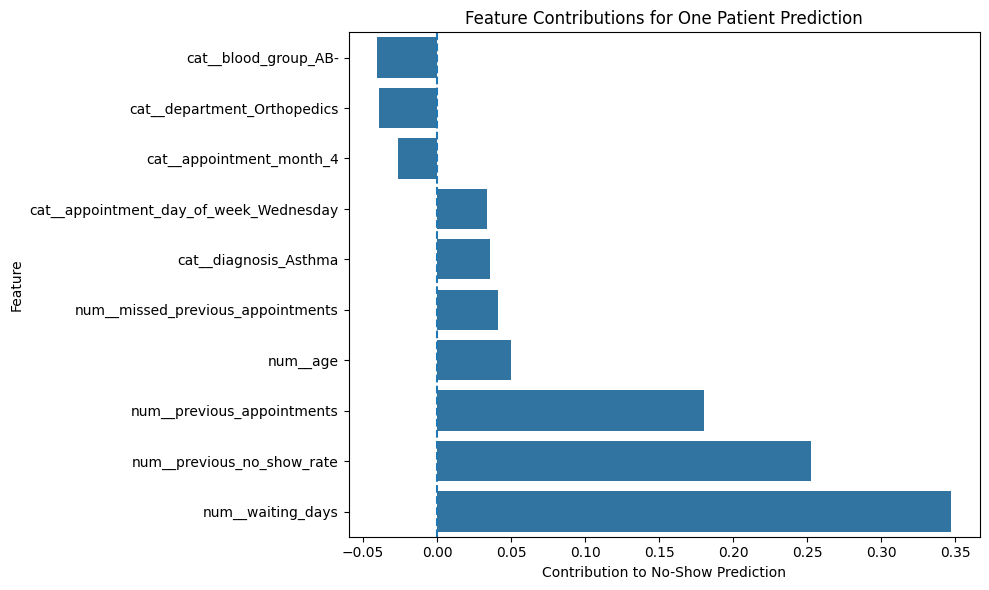

In [96]:
top_local = (
    local_explanation
    .head(10)
    .sort_values(
        by="Contribution"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_local,
    x="Contribution",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Feature Contributions for One Patient Prediction"
)

plt.xlabel(
    "Contribution to No-Show Prediction"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

## 9. Transparency



The selected Logistic Regression model provides better interpretability
than many complex black-box algorithms because the direction and
relative influence of model coefficients can be examined.

Global feature importance allows hospital staff to understand the
factors used by the model overall.

Individual contribution analysis can also be used to investigate why a
specific appointment received a particular prediction.

This improves transparency and allows users to examine the model rather
than relying only on an unexplained prediction.

## 10. Ethical implications

Although the prediction model may support hospital appointment
management, its results should not be treated as unquestionable
decisions

A patient predicted as a high no-show risk may still attend the
appointment. Therefore, the model should be used as a decision-support
tool rather than a system for denying or cancelling appointments

Demographic variables such as age and gender must also be treated
carefully because inappropriate use could introduce or reinforce unfair
treatment of particular patient groups

False-positive predictions may result in patients being unnecessarily
labelled as high-risk, while false-negative predictions may cause the
hospital to miss opportunities for useful interventions

Patient information should be stored securely and accessed only for
appropriate healthcare purposes because the dataset contains sensitive
health-related information

Model performance and fairness should also be monitored over time
because patient behaviour and hospital processes may change

## 11. Task 07 conclusion

Feature Importance Analysis was used to explain the selected Logistic
Regression model.

Both coefficient analysis and permutation importance identified
`waiting_days` as the strongest predictive feature.

Previous appointment behaviour, including missed previous appointments
and previous no-show rate, also contributed to no-show prediction.

Individual contribution analysis demonstrated how the model can provide
reasoning for a specific patient's prediction.

The analysis improves model transparency; however, predictions should
be used to support human decision-making rather than automatically
penalizing or denying services to patients.